<a href="https://colab.research.google.com/github/mennashahin129-beep/Diabetes-Risk-Prediction-System/blob/main/diabetes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import RandomOverSampler


In [2]:
df = pd.read_csv("/content/archive (1) (1).zip")   # Load Dataset


In [3]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
df.shape

(100000, 31)

In [5]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

#Data Cleaning

In [7]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [8]:
df.duplicated().sum()

np.int64(0)

#Encoding

In [9]:
# Drop leakage column
df.drop(columns=["diabetes_stage"], inplace=True)

# Binary encoding
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

# Ordinal encoding
df["education_level"] = df["education_level"].map({
    "Primary": 0,
    "Secondary": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
})

df["income_level"] = df["income_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Very High": 3
})

df["smoking_status"] = df["smoking_status"].map({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

# One-Hot encoding
df = pd.get_dummies(
    df,
    columns=["ethnicity", "employment_status"],
    drop_first=True
)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              97987 non-null   float64
 2   education_level                     0 non-null       float64
 3   income_level                        19832 non-null   float64
 4   smoking_status                      100000 non-null  int64  
 5   alcohol_consumption_per_week        100000 non-null  int64  
 6   physical_activity_minutes_per_week  100000 non-null  int64  
 7   diet_score                          100000 non-null  float64
 8   sleep_hours_per_day                 100000 non-null  float64
 9   screen_time_hours_per_day           100000 non-null  float64
 10  family_history_diabetes             100000 non-null  int64  
 11  hypertension_history       

#Correlation

diagnosed_diabetes                    1.000000
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
diastolic_bp                          0.035619
cardiovascular_history                0.029793
hypertension_history                  0.027524
heart_rate                            0.022785
screen_time_hours_per_day             0.018127
income_level                          0.005872
ethnicity_Other                       0.003608
gender       

/tmp/ipykernel_4186/3115614825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


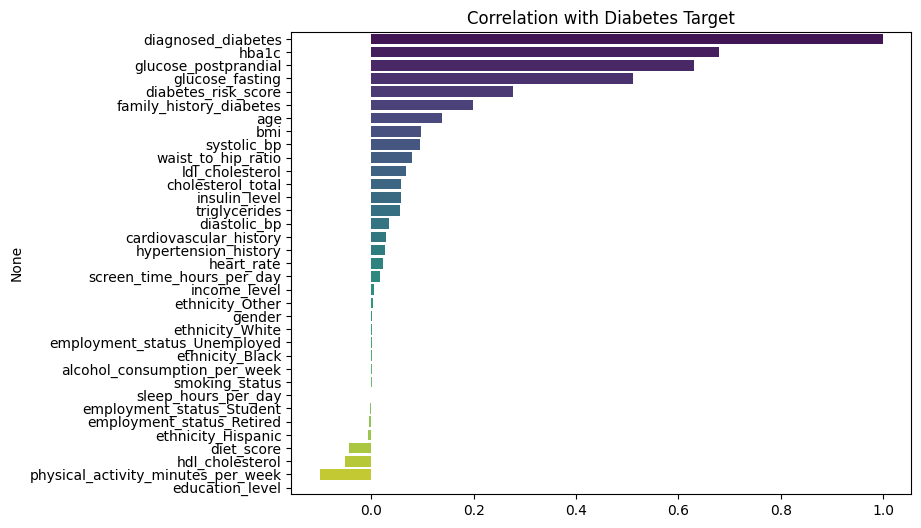

Selected Features: ['hba1c', 'glucose_postprandial', 'glucose_fasting', 'diabetes_risk_score', 'family_history_diabetes', 'age', 'physical_activity_minutes_per_week', 'bmi', 'systolic_bp', 'waist_to_hip_ratio']


In [11]:
corr = df.corr()

# Correlation with target
target_corr = corr["diagnosed_diabetes"].sort_values(ascending=False)

print(target_corr)

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette="viridis"
)
plt.title("Correlation with Diabetes Target")
plt.show()

# ===============================
# 6. Select Top Correlated Features
# ===============================
# Remove target itself
top_features = target_corr.drop("diagnosed_diabetes")

# Select top N features based on absolute correlation
selected_features = top_features.abs().sort_values(ascending=False).head(10).index.tolist()

print("Selected Features:", selected_features)


In [12]:
joblib.dump(selected_features, "selected_features.pkl")


['selected_features.pkl']

In [13]:
# Select Features Used in the Model


X = df[selected_features]
y = df["diagnosed_diabetes"]


#Outliers

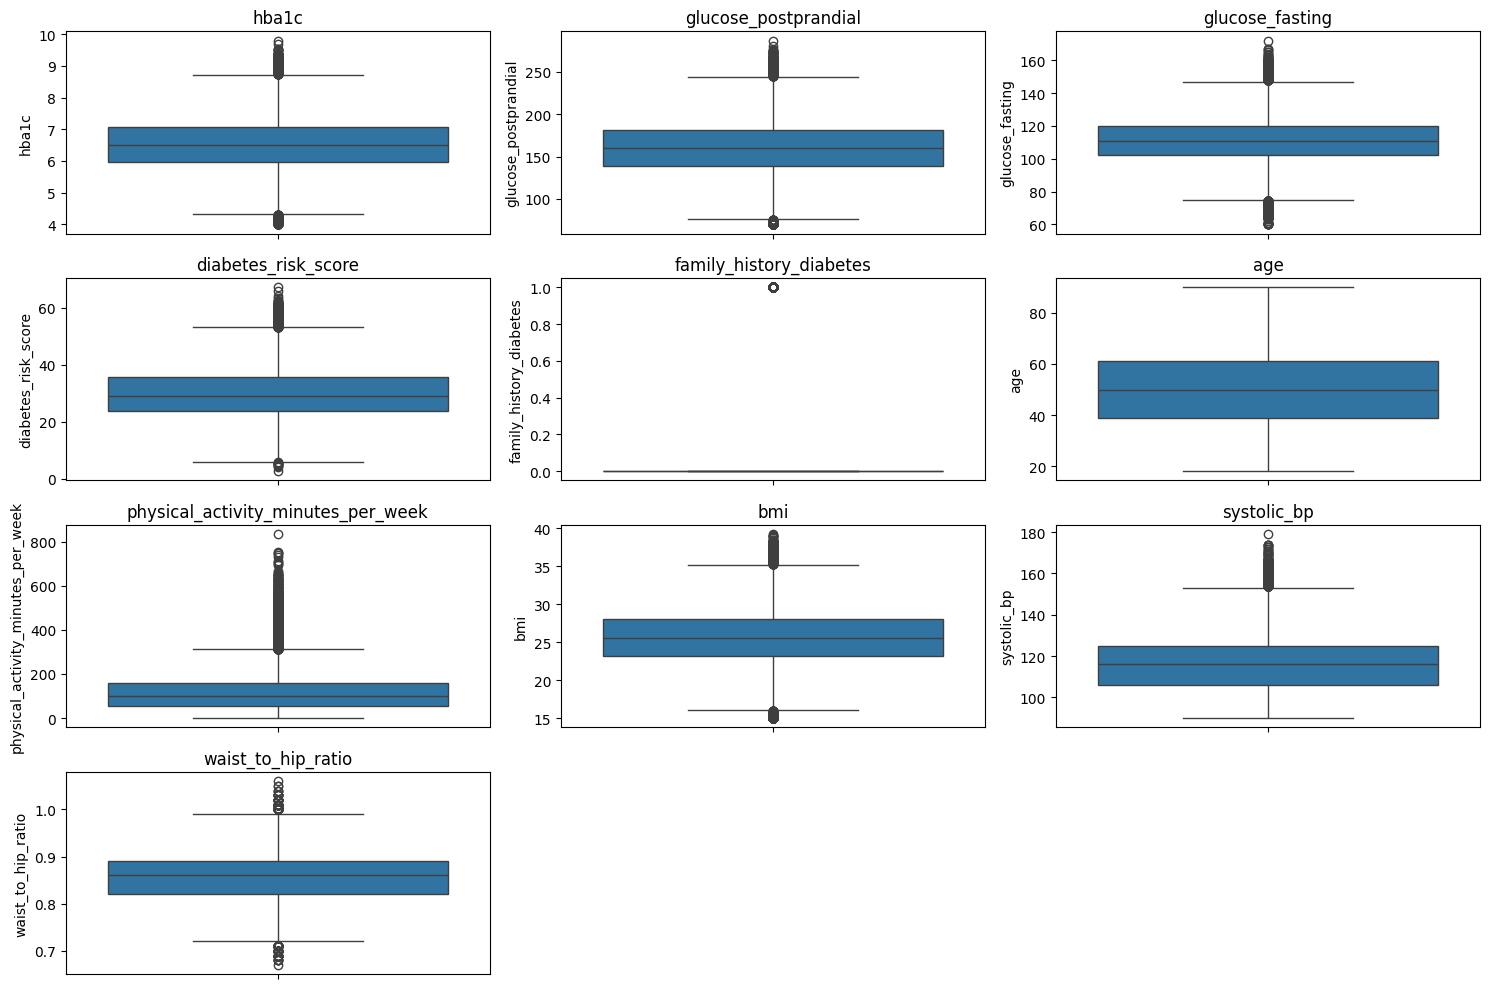

In [14]:
#  Visual Analysis (Before Cleaning)
plt.figure(figsize=(15, 10))

for i, col in enumerate(selected_features):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


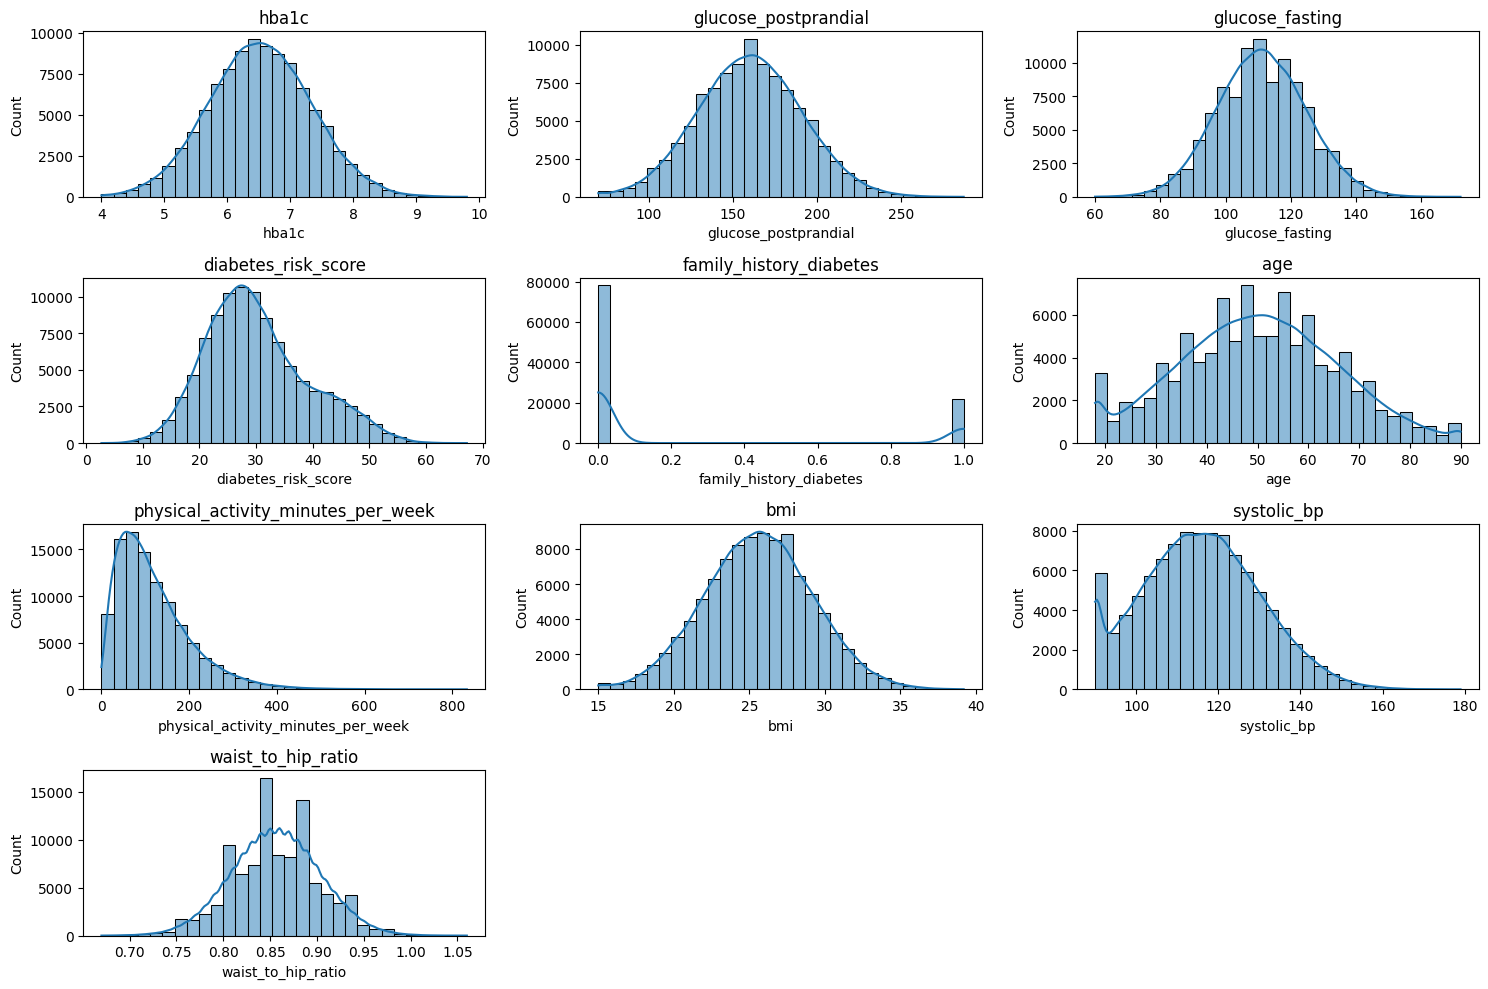

In [15]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(selected_features):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


In [16]:
# Outlier Detection using IQR

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


In [17]:
#  Handle Outliers using Clipping

for col in selected_features:
    if df[col].nunique() > 2:
        outliers, _, _ = detect_outliers_iqr(df, col)
        print(f"{col}: {outliers.shape[0]} outliers")


hba1c: 618 outliers
glucose_postprandial: 634 outliers
glucose_fasting: 745 outliers
diabetes_risk_score: 914 outliers
age: 0 outliers
physical_activity_minutes_per_week: 3199 outliers
bmi: 744 outliers
systolic_bp: 530 outliers
waist_to_hip_ratio: 273 outliers


In [18]:
df_clean = df.copy()

for col in selected_features:
    if df_clean[col].nunique() > 2:
        _, lb, ub = detect_outliers_iqr(df_clean, col)
        df_clean[col] = df_clean[col].clip(lower=lb, upper=ub)


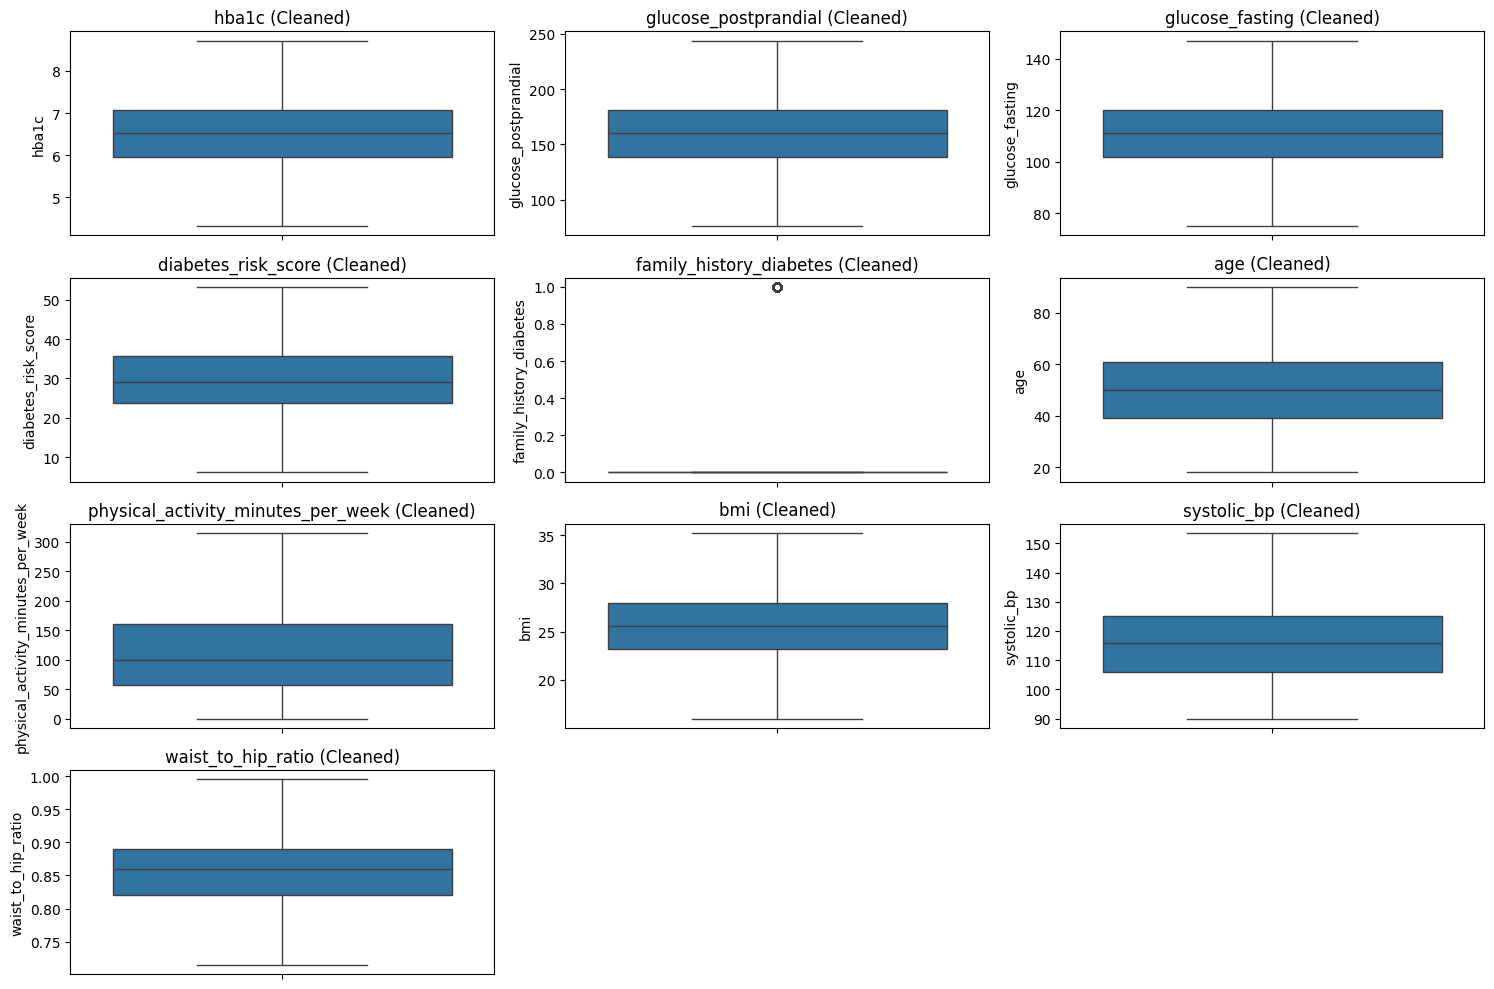

In [19]:
#  Visual Confirmation (After Cleaning)

plt.figure(figsize=(15, 10))

for i, col in enumerate(selected_features):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f"{col} (Cleaned)")

plt.tight_layout()
plt.show()


In [20]:
#  Prepare Features and Target

X = df_clean[selected_features]
y = df_clean["diagnosed_diabetes"]


In [21]:
#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [22]:
#  Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


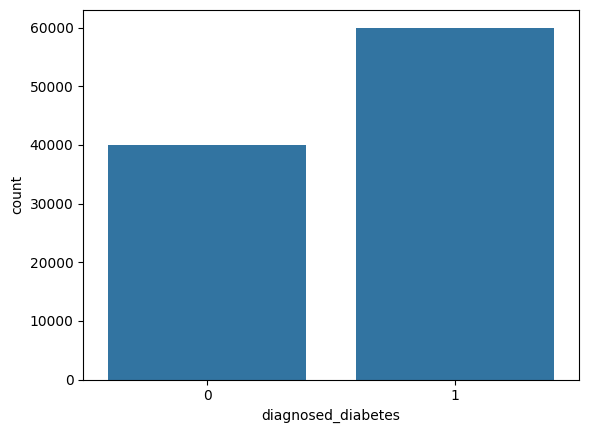

In [23]:
sns.countplot(x='diagnosed_diabetes', data=df_clean)
plt.show()


In [24]:
#  Handle Class Imbalance (Oversampling)

ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)


In [25]:
#  Define Models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1
    ),

    "Linear SVC": LinearSVC(max_iter=3000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights='distance'
    )
}


In [26]:
#  Train and Evaluate Models

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

    print(name)
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print("-"*40)


Logistic Regression
Accuracy : 0.8882
Precision: 0.9315
Recall   : 0.8782
F1 Score : 0.9041
----------------------------------------
Linear SVC
Accuracy : 0.8873
Precision: 0.9299
Recall   : 0.8783
F1 Score : 0.9034
----------------------------------------
Random Forest
Accuracy : 0.9199
Precision: 0.9999
Recall   : 0.8666
F1 Score : 0.9285
----------------------------------------
Gradient Boosting
Accuracy : 0.9199
Precision: 1.0000
Recall   : 0.8665
F1 Score : 0.9285
----------------------------------------
KNN
Accuracy : 0.8669
Precision: 0.9480
Recall   : 0.8233
F1 Score : 0.8813
----------------------------------------


In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["F1", "Recall"], ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.9199,0.999904,0.866583,0.928482
3,Gradient Boosting,0.9199,1.000000,0.866500,0.928476
0,Logistic Regression,0.8882,0.931501,0.878250,0.904092
1,Linear SVC,0.8873,0.929945,0.878333,0.903403
4,KNN,0.8669,0.947995,0.823333,0.881277


In [28]:
#  Select Best Model
#Accuracy alone is not sufficient for medical diagnosis  F1-score and recall were prioritized to ensure a balanced and safe prediction of diabetes risk.
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# ✅ IMPORTANT: Retrain best model on full training data
best_model.fit(X_train, y_train)

print("Best Model Selected:", best_model_name)


Best Model Selected: Random Forest


In [29]:
# Save Model Artifacts
print(type(best_model))

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save feature means for handling missing inputs in GUI

feature_means = X.mean().to_dict()
joblib.dump(feature_means, "feature_means.pkl")


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


['feature_means.pkl']

In [30]:
import gradio as gr
import numpy as np
import joblib

# =========================
# Load saved artifacts
# =========================
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_means = joblib.load("feature_means.pkl")
selected_features = joblib.load("selected_features.pkl")

feature_names = list(feature_means.keys())

# =========================
# Prediction Function
# =========================
def predict_diabetes(*inputs):
    x = []

    # Handle missing values using feature means
    for i, val in enumerate(inputs):
        if val is None or val == "":
            x.append(feature_means[feature_names[i]])
        else:
            x.append(float(val))

    x = np.array(x).reshape(1, -1)
    x = scaler.transform(x)

    # Get probabilities
    proba = model.predict_proba(x)[0]
    low_prob = proba[0]
    high_prob = proba[1]

    # =========================
    # Risk Levels + Recommendations
    # =========================
    if high_prob >= 0.6:
        return (
            "🔴 High Risk of Diabetes\n"
            f"Confidence: {high_prob*100:.1f}%\n\n"
            "🩺 Lifestyle Recommendations:\n"
            "- Consult a healthcare professional\n"
            "- Monitor blood glucose regularly\n"
            "- Reduce sugar & refined carbohydrates\n"
            "- Increase physical activity\n"
            "- Weight management is strongly advised"
        )

    elif high_prob >= 0.4:
        return (
            "🟡 Moderate Risk of Diabetes\n"
            f"Confidence: {high_prob*100:.1f}%\n\n"
            "🩺 Lifestyle Recommendations:\n"
            "- Follow a balanced, healthy diet\n"
            "- Exercise at least 150 minutes per week\n"
            "- Monitor blood glucose periodically\n"
            "- Reduce sedentary lifestyle\n"
            "- Consider follow-up lab tests"
        )

    else:
        return (
            "🟢 Low Risk of Diabetes\n"
            f"Confidence: {low_prob*100:.1f}%\n\n"
            "🩺 Lifestyle Recommendations:\n"
            "- Maintain a healthy lifestyle\n"
            "- Continue regular physical activity\n"
            "- Eat a balanced diet\n"
            "- Routine medical check-ups are recommended"
        )

inputs = [
    gr.Number(label=feature.replace("_", " ").title())
    for feature in selected_features
]

demo = gr.Interface(
    fn=predict_diabetes,
    inputs=inputs,
    outputs=gr.Textbox(lines=12),
    title="🩺 Diabetes Risk Prediction System",
    description=(
        "Enter health-related values to predict diabetes risk.\n"
        "The system provides risk level, confidence score, and lifestyle recommendations.\n\n"
        "⚠️ This tool is for educational purposes only and does not replace medical advice."
    ),
)

# =========================
# Launch App
# =========================
demo.launch()




It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://322928c50c2f560b33.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
